# 02. Preprocessing и feature engineering (v3)

Вход: 14 сырых parquet'ов (234.6M rows, ~37 700 рейсов).
Выход: очищенный parquet с европейскими рейсами и 21 колонкой (5 metadata + 9 модельных признаков + 7 DQ-флагов). Без молчаливой импутации артефактов.

## Замечания по реализации (vs предыдущая версия)

Основной фикс: spike-фильтр в предыдущей версии возвращал `arr_filled` (с заменёнными на ffill+bfill NaN), и threshold-NaN молчаливо превращались обратно в числа. Теперь функция работает с `arr.copy()` и явно восстанавливает исходные NaN перед возвратом. Подсчёт `n_changed` идёт через `np.isclose(equal_nan=True)`.

Добавлены DQ-флаги в виде uint8: три флага threshold_bad (altitude/groundspeed/vertical_rate), три флага spike_corrected на те же каналы, и stale_altitude. Это то, что пропускалось раньше: точки, заблокированные пороговым фильтром или исправленные медианой, теперь видимы downstream.

Stale altitude detection переписан с одной-точечного на run-level: altitude должна быть константой в пределах ±25 ft на длительности ≥ 60 последовательных samples, при этом ≥ 50% валидных VR-точек внутри run должны быть активны. Прежнее условие точного равеса по одной точке давало много ложных срабатываний.

В quality-check добавлен sanity-check по dt_sec (диагностика временной непрерывности) и unit-тесты для headwind/crosswind на synthetic-кейсах. Sensitivity analysis для порога `active_share` в stale detection вынесен в отдельный диагностический ноутбук.

## Пайплайн

1. Последовательная загрузка файлов (RAM-safe).
2. Фильтрация по европейскому bbox (lat 35-72, lon −15-40).
3. Дедупликация рейсов между файлами (owner-file механизм).
4. Threshold filter: флаги плюс NaN.
5. Spike filter: флаги и исправления, NaN сохраняем.
6. Stale altitude detection (run-level).
7. Производные признаки (acceleration, turn rate, vertical accel, ветровые компоненты).
8. Удаление избыточных признаков (temperature, specific_humidity).
9. Quality check и сохранение.

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import glob
import os
import gc
import time
from scipy.ndimage import median_filter

Mounted at /content/drive


In [ ]:
# Конфигурация
DATA_DIR = '/content/drive/MyDrive/OSN - parquets'  # сырые данные
OUTPUT_DIR = '/content/drive/MyDrive/thesis_processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Европейский bbox
LAT_MIN, LAT_MAX = 35.0, 72.0
LON_MIN, LON_MAX = -15.0, 40.0

# Пороги артефактов ADS-B
ALT_MAX = 60000       # ft, выше артефакт
ALT_MIN = -500        # ft, ниже артефакт
GS_MAX = 600          # kts, выше артефакт
VR_ABS_MAX = 10000    # ft/min, по модулю выше артефакт

# Параметры spike-фильтра
MEDIAN_WINDOW = 7     # точек (7с при 1 Гц)
MEDIAN_THRESH_ALT = 1000   # ft
MEDIAN_THRESH_GS = 50      # kts
MEDIAN_THRESH_VR = 2000    # ft/min

# Stale altitude detection
STALE_ALT_MIN_POINTS = 60   # последовательных samples (~60 с при 1 Гц, явные gaps обрабатываются в 02c)
STALE_VR_THRESHOLD = 500      # ft/min, VR считается активным
STALE_MIN_ALTITUDE = 10000    # ft, ниже не проверяем (квантование ADS-B при approach)
STALE_ACTIVE_SHARE = 0.5      # доля точек run с активным VR
ALT_STALE_TOL = 25            # ft, допуск равенства altitude в run

# Производные признаки
DIFF_N = 5  # шаг wide differencing (окно 10 с при 1 Гц)

In [ ]:
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.parquet')))
print(f'Found {len(parquet_files)} files')

Found 14 files


### Конфигурация пайплайна

Все пороги и параметры вынесены в начало ноутбука, в одном месте удобно править и воспроизводить. Значения взяты из EDA и инженерных соображений.

Европейский bbox (lat 35-72°, lon −15-40°). Ограничивает анализ территорией с плотным покрытием наземными ADS-B приёмниками. За пределами bbox покрытие разреженное, данные фрагментарны и ненадёжны для обнаружения аномалий.

Пороги артефактов ADS-B. Определены из персентилей в EDA, зазор между P99.9 реальных данных и физически невозможными значениями:
- altitude ∈ [−500, 60 000] ft. P99.9 = 43 000 ft, верхняя граница с запасом относительно потолка коммерческой авиации.
- groundspeed ≤ 600 kts. P99.9 = 572 kts, выше недостоверно (max в сырых данных 1 115 kts).
- |vertical_rate| ≤ 10 000 ft/min. P99.9 = 4 224 ft/min, выше артефакт квантования (max 32 640 ft/min).

Значения за порогами недостоверные, заменяются на NaN. Соответствующие `*_threshold_bad` флаги сохраняются для downstream-анализа.

Spike filter (медианный):
- Окно 7 точек (7 секунд при 1 Гц), достаточно для подавления спайков до 3 точек, не затрагивает реальные манёвры (десятки секунд).
- Пороги отклонения: altitude 1 000 ft, groundspeed 50 kts, vertical_rate 2 000 ft/min.
- Двухсторонняя проверка через левую и правую медианы (sides_agree) исключает срабатывание на длинных плато.
- Соответствующие `*_spike_corrected` флаги сохраняются.

Stale altitude detection:
- Минимальная длительность плато: 60 последовательных samples (~60 секунд при 1 Гц, явная обработка временных gaps в 02c).
- Минимальная высота: 10 000 ft (ниже не проверяем, там часто легитимное квантование при подходе).
- Tolerance: 25 ft (соответствует дискретизации ADS-B altitude).
- Условие срабатывания: altitude константна (в пределах tolerance) ≥60 сек, при этом ≥50% валидных VR-точек внутри run имеют |VR| > 500 ft/min.

Wide differencing N=5. Расширенное дифференцирование с шагом ±5 точек (окно 10 секунд). Выбрано в EDA как баланс между подавлением дискретности квантования и сохранением чувствительности к реальным манёврам.

## 2. Определение европейских рейсов

Лёгкий проход по всем файлам: для каждого рейса считаем долю точек внутри европейского bbox. Рейс считается европейским, если ≥95% его точек попадают внутрь. Это отсекает трансатлантические рейсы, которые лишь частично пересекают Европу.

Порог 80% тестировался в EDA, отвергнут по итогам визуальной валидации.

In [ ]:
# Pass 1: какие рейсы европейские (агрегируем по всем файлам)
# и какой файл владеет каждым рейсом (первое появление)

flight_totals = {}   # flight_id -> {'n_total': int, 'n_in_bbox': int, 'owner': int}

for i, f in enumerate(parquet_files):
    t0 = time.time()
    tmp = pd.read_parquet(f, columns=['flight_id', 'latitude', 'longitude'])

    in_bbox = (
        (tmp['latitude'] >= LAT_MIN) & (tmp['latitude'] <= LAT_MAX) &
        (tmp['longitude'] >= LON_MIN) & (tmp['longitude'] <= LON_MAX)
    )

    stats = tmp.groupby('flight_id').agg(
        n_total=('latitude', 'size'),
        n_in_bbox=('latitude', lambda x: in_bbox.loc[x.index].sum())
    )

    for fid, row in stats.iterrows():
        if fid not in flight_totals:
            flight_totals[fid] = {'n_total': 0, 'n_in_bbox': 0, 'owner': i}
        flight_totals[fid]['n_total'] += row['n_total']
        flight_totals[fid]['n_in_bbox'] += row['n_in_bbox']

    dt = time.time() - t0
    print(f'  [{i+1:2d}/14] {os.path.basename(f)}: {len(stats)} flights, {dt:.1f}s')
    del tmp, stats, in_bbox

# eu_ratio считаем по полным данным рейса из всех файлов
flight_owner = {}
flight_eu_ratio = {}
for fid, info in flight_totals.items():
    flight_owner[fid] = info['owner']
    flight_eu_ratio[fid] = info['n_in_bbox'] / info['n_total']

# Один порог 95% (по визуальной валидации в EDA)
EU_THRESHOLD = 0.95
eu_flights = {fid for fid, ratio in flight_eu_ratio.items() if ratio >= EU_THRESHOLD}

print(f'\nTotal unique flights: {len(flight_totals)}')
print(f'European flights (>= {EU_THRESHOLD:.0%} in bbox): {len(eu_flights)}')
print(f'Excluded: {len(flight_totals) - len(eu_flights)}')

del flight_totals

  [ 1/14] 2022-11-01.parquet: 2735 flights, 14.0s
  [ 2/14] 2022-11-02.parquet: 2774 flights, 14.4s
  [ 3/14] 2022-11-03.parquet: 2855 flights, 16.4s
  [ 4/14] 2022-11-04.parquet: 2896 flights, 13.7s
  [ 5/14] 2022-11-05.parquet: 2426 flights, 14.2s
  [ 6/14] 2022-11-06.parquet: 2827 flights, 15.0s
  [ 7/14] 2022-11-07.parquet: 2799 flights, 13.7s
  [ 8/14] 2022-11-08.parquet: 2570 flights, 12.8s
  [ 9/14] 2022-11-09.parquet: 2524 flights, 9.1s
  [10/14] 2022-11-10.parquet: 2789 flights, 13.2s
  [11/14] 2022-11-11.parquet: 2832 flights, 18.6s
  [12/14] 2022-11-12.parquet: 2250 flights, 14.2s
  [13/14] 2022-11-13.parquet: 2713 flights, 15.9s
  [14/14] 2022-11-14.parquet: 2742 flights, 14.8s

Total unique flights: 37732
European flights (≥95% in bbox): 29788
Excluded: 7944


0

### Пространственная фильтрация и дедупликация (Pass 1)

Первый проход по всем 14 файлам решает две задачи одновременно.

1. Определение европейских рейсов. Для каждого рейса вычисляется доля точек, попадающих в европейский bbox. Рейс считается европейским, если ≥95% его точек внутри bbox. Порог 95% (а не 80% или 100%) выбран по итогам визуальной валидации: при 80% сохранялись трансатлантические рейсы с длинными океанскими сегментами, при 100% терялись рейсы, у которых несколько секунд записи попадают чуть за границу bbox. 95% это баланс: неевропейские отсекаются, приграничные сохраняются.

Важно: фильтруются именно целые рейсы, а не отдельные точки. Обрезка точек по bbox отвергнута, она привела бы к потере фаз взлёта и посадки у приграничных рейсов, что критично для LSTM-autoencoder на полных последовательностях.

2. Дедупликация между файлами. Файлы перекрываются по времени (рейс, начавшийся вечером, попадает и в файл текущего дня, и следующего). Каждому рейсу назначается файл-владелец, тот, в котором flight_id встретился впервые. При обработке каждый файл загружает только свои рейсы, дублирование исключено.

Ожидаемый результат: из ~37 700 уникальных рейсов отобрано ~29 800 европейских (~79%). Исключено ~7 900 рейсов: трансатлантические, ближневосточные, африканские и азиатские направления.

Инженерная деталь: Pass 1 загружает только 3 колонки (flight_id, latitude, longitude) из каждого parquet-файла, экономит RAM по сравнению с полной загрузкой 13 колонок.

## 3. Функции обработки

Пять функций, составляющих пайплайн очистки одного файла.

`apply_threshold_filter`: пороговая фильтрация. Значения за пределами физически допустимых диапазонов заменяются на NaN, помечаются `*_threshold_bad` флаги.

`apply_spike_filter_flight`: spike-фильтр для одного рейса. Двухсторонняя проверка (левая и правая медианы) с условием `sides_agree`, что исключает срабатывание на длинных плато (stale data). Важно: функция возвращает массив, построенный от `arr.copy()`, с явным восстановлением NaN, без молчаливой импутации.

`apply_spike_filters`: обёртка через flight boundaries (numpy slices, без `groupby.transform`). Применяет spike-фильтр к altitude, groundspeed, vertical_rate, добавляет `*_spike_corrected` флаги.

`detect_stale_altitude`: run-level cross-channel consistency check, altitude константна (в пределах ±25 ft) ≥60 сек, при этом ≥50% валидных VR-точек внутри run активны (>500 ft/min).

`compute_features`: wide differencing (N=5, окно 10 с) для acceleration, turn_rate, vertical_accel, плюс ветровые компоненты wind_speed/headwind/crosswind. Маска `same_flight` исключает дифференцирование через границы рейсов.

`select_final_columns`: отбор 21 колонки, 5 metadata + 9 модельных признаков + 7 DQ-флагов.

In [ ]:
def apply_threshold_filter(df):
    """Замена физически невозможных значений на NaN. Сохраняет флаги."""
    df['altitude_threshold_bad'] = (
        (df['altitude'] > ALT_MAX) | (df['altitude'] < ALT_MIN)
    ).astype(np.uint8)
    df['groundspeed_threshold_bad'] = (df['groundspeed'] > GS_MAX).astype(np.uint8)
    df['vertical_rate_threshold_bad'] = (df['vertical_rate'].abs() > VR_ABS_MAX).astype(np.uint8)

    df.loc[df['altitude_threshold_bad'] == 1, 'altitude'] = np.nan
    df.loc[df['groundspeed_threshold_bad'] == 1, 'groundspeed'] = np.nan
    df.loc[df['vertical_rate_threshold_bad'] == 1, 'vertical_rate'] = np.nan

    return df


def apply_spike_filter_flight(values, threshold):
    """Spike-фильтр для одного рейса. Возвращает (cleaned_values, replace_mask)."""
    n = len(values)
    if n < MEDIAN_WINDOW:
        return values, np.zeros(n, dtype=bool)

    arr = values.copy()
    mask_nan = np.isnan(arr)

    if mask_nan.all():
        return arr, np.zeros(n, dtype=bool)

    # ffill+bfill только для расчёта медиан, не для финального out
    arr_filled = pd.Series(arr).ffill().bfill().to_numpy()
    half = MEDIAN_WINDOW // 2

    shifted_right = np.concatenate([np.full(half, arr_filled[0]), arr_filled[:-half]])
    shifted_left = np.concatenate([arr_filled[half:], np.full(half, arr_filled[-1])])

    left_med = median_filter(shifted_right, size=half)
    right_med = median_filter(shifted_left, size=half)

    sides_agree = np.abs(left_med - right_med) < threshold
    point_is_outlier = (
        (np.abs(arr_filled - left_med) > threshold) &
        (np.abs(arr_filled - right_med) > threshold)
    )

    replace_mask = sides_agree & point_is_outlier & (~mask_nan)

    # КРИТИЧНО: out строится от arr.copy(), не от arr_filled
    out = arr.copy()
    out[replace_mask] = (left_med[replace_mask] + right_med[replace_mask]) / 2
    # Явное восстановление NaN на всякий случай
    out[mask_nan] = np.nan

    return out, replace_mask


def apply_spike_filters(df):
    """Spike-фильтр для altitude, groundspeed, vertical_rate."""
    df = df.sort_values(['flight_id', 'timestamp']).reset_index(drop=True)

    flight_ids = df['flight_id'].to_numpy()
    boundaries = np.concatenate([
        [0],
        np.where(np.diff(flight_ids) != 0)[0] + 1,
        [len(df)]
    ])

    total_corrected = 0

    for col, thresh in [('altitude', MEDIAN_THRESH_ALT),
                        ('groundspeed', MEDIAN_THRESH_GS),
                        ('vertical_rate', MEDIAN_THRESH_VR)]:
        col_arr = df[col].to_numpy().copy()
        flags_arr = np.zeros(len(df), dtype=np.uint8)

        for k in range(len(boundaries) - 1):
            s, e = boundaries[k], boundaries[k+1]
            cleaned, replaced = apply_spike_filter_flight(col_arr[s:e], thresh)
            col_arr[s:e] = cleaned
            flags_arr[s:e] = replaced.astype(np.uint8)

        df[col] = col_arr
        df[f'{col}_spike_corrected'] = flags_arr
        n_changed = int(flags_arr.sum())
        total_corrected += n_changed
        if n_changed > 0:
            print(f'    spike filter [{col}]: {n_changed} points corrected')

    return df, total_corrected


def detect_stale_altitude(df, active_share_thr=STALE_ACTIVE_SHARE):
    """Помечает точки stale altitude."""
    df = df.sort_values(['flight_id', 'timestamp']).copy()

    def mark_stale_in_flight(group):
        alt = group['altitude'].to_numpy()
        vr = group['vertical_rate'].to_numpy()
        n = len(alt)
        stale = np.zeros(n, dtype=bool)

        if n < STALE_ALT_MIN_POINTS:
            return pd.Series(stale, index=group.index)

        run_start = 0

        # Идём до n включительно, чтобы корректно закрыть последний run
        for i in range(1, n + 1):
            end_run = False

            if i == n:
                end_run = True
            elif np.isnan(alt[i]) or np.isnan(alt[run_start]):
                end_run = True
            elif abs(alt[i] - alt[run_start]) > ALT_STALE_TOL:
                end_run = True

            if end_run:
                run_end = i
                run_len = run_end - run_start

                if run_len >= STALE_ALT_MIN_POINTS:
                    run_alt = alt[run_start:run_end]
                    run_vr = vr[run_start:run_end]
                    valid_vr = run_vr[~np.isnan(run_vr)]

                    if len(valid_vr) > 0:
                        active_share = (np.abs(valid_vr) > STALE_VR_THRESHOLD).mean()
                        median_alt = np.nanmedian(run_alt)

                        if (median_alt > STALE_MIN_ALTITUDE and
                            active_share >= active_share_thr):
                            stale[run_start:run_end] = True

                run_start = i
                # Если run закрылся из-за NaN, перематываем до следующего валидного
                while run_start < n and np.isnan(alt[run_start]):
                    run_start += 1
                # После перемотки i может быть < run_start, цикл сам подтянется

        return pd.Series(stale, index=group.index)

    df['stale_altitude'] = (
        df.groupby('flight_id', group_keys=False)
        .apply(mark_stale_in_flight)
        .astype(np.uint8)
    )

    return df


def compute_features(df):
    """Производные кинематические и ветровые признаки."""
    df = df.sort_values(['flight_id', 'timestamp']).reset_index(drop=True)

    N = DIFF_N
    fid = df['flight_id'].values
    ts = df['timestamp'].astype('int64').to_numpy() / 1e9  # секунды

    # Шаг времени на интервале 2N
    dt_wide = np.full(len(df), np.nan)
    dt_wide[N:-N] = ts[2*N:] - ts[:-2*N]

    # Маска принадлежности одному рейсу
    same_flight = np.ones(len(df), dtype=bool)
    same_flight[:N] = False
    same_flight[-N:] = False
    for k in range(1, 2*N + 1):
        mask = np.zeros(len(df), dtype=bool)
        mask[k:] = fid[k:] == fid[:-k]
        same_flight &= mask
    dt_wide[~same_flight] = np.nan

    def wide_diff(col_values):
        d = np.full(len(col_values), np.nan)
        d[N:-N] = col_values[2*N:] - col_values[:-2*N]
        d[~same_flight] = np.nan
        result = d / dt_wide
        result[~np.isfinite(result)] = np.nan
        return result

    # Acceleration (kts/s)
    df['acceleration'] = wide_diff(df['groundspeed'].values)

    # Vertical acceleration (ft/min/s)
    df['vertical_accel'] = wide_diff(df['vertical_rate'].values)

    # Turn rate (deg/s), wraparound учитываем
    track_vals = df['track'].values
    td = np.full(len(track_vals), np.nan)
    td[N:-N] = track_vals[2*N:] - track_vals[:-2*N]
    td = ((td + 180) % 360) - 180
    td[~same_flight] = np.nan
    df['turn_rate'] = td / dt_wide
    df.loc[~np.isfinite(df['turn_rate']), 'turn_rate'] = np.nan

    # Скорость и направление ветра из u/v компонент (ERA5)
    df['wind_speed'] = np.sqrt(df['u_component_of_wind']**2 +
                               df['v_component_of_wind']**2)
    wind_dir = np.degrees(np.arctan2(-df['u_component_of_wind'],
                                      -df['v_component_of_wind']))
    df['wind_dir'] = (wind_dir + 360) % 360

    # Headwind и crosswind
    track_rad = np.radians(df['track'])
    wind_rad = np.radians(df['wind_dir'])
    angle_diff = wind_rad - track_rad
    df['headwind'] = df['wind_speed'] * np.cos(angle_diff)
    df['crosswind'] = df['wind_speed'] * np.abs(np.sin(angle_diff))

    return df


def select_final_columns(df):
    """Оставить 21 колонку: 5 metadata + 9 модельных признаков + 7 DQ-флагов."""
    keep = [
        # Metadata (5)
        'flight_id', 'timestamp', 'latitude', 'longitude', 'icao24',
        # Модельные признаки (9)
        'altitude', 'groundspeed', 'vertical_rate',
        'acceleration', 'turn_rate', 'vertical_accel',
        'wind_speed', 'headwind', 'crosswind',
        # DQ-флаги (7)
        'altitude_threshold_bad', 'groundspeed_threshold_bad', 'vertical_rate_threshold_bad',
        'altitude_spike_corrected', 'groundspeed_spike_corrected', 'vertical_rate_spike_corrected',
        'stale_altitude'
    ]
    return df[keep]


print('Functions defined.')

Functions defined.


### Unit-тест headwind / crosswind

Проверяем знаки на трёх synthetic-сценариях (встречный ветер, попутный, боковой). Формула с `arctan2(-u, -v)` неинтуитивная, без теста легко ошибиться знаком.

In [ ]:
def _test_wind_decomposition():
    """Synthetic-тесты для проверки знаков headwind/crosswind."""

    def compute_wind(u, v, track):
        u, v, track = np.array([u]), np.array([v]), np.array([track])
        wind_speed = np.sqrt(u**2 + v**2)
        wind_dir = np.degrees(np.arctan2(-u, -v))
        wind_dir = (wind_dir + 360) % 360
        track_rad = np.radians(track)
        wind_rad = np.radians(wind_dir)
        angle_diff = wind_rad - track_rad
        headwind = wind_speed * np.cos(angle_diff)
        crosswind = wind_speed * np.abs(np.sin(angle_diff))
        return float(headwind[0]), float(crosswind[0])

    # Test 1: летим на север (track=0), ветер с севера на юг (v=-10), встречный
    hw, cw = compute_wind(u=0, v=-10, track=0)
    assert abs(hw - 10) < 1e-6
    assert abs(cw) < 1e-6

    # Test 2: летим на север (track=0), ветер с юга на север (v=+10), попутный
    hw, cw = compute_wind(u=0, v=10, track=0)
    assert abs(hw + 10) < 1e-6
    assert abs(cw) < 1e-6

    # Test 3: летим на север (track=0), ветер с запада на восток (u=+10), боковой
    hw, cw = compute_wind(u=10, v=0, track=0)
    assert abs(hw) < 1e-6
    assert abs(cw - 10) < 1e-6

    print('Wind decomposition unit-tests passed (headwind, crosswind).')

_test_wind_decomposition()

Wind decomposition unit-tests passed (headwind, crosswind).


### Тест spike-фильтра

Проверяем три случая:
1. Одиночный spike на согласованном фоне должен исправляться.
2. Плато не должно трогаться (все точки stale остаются на месте).
3. NaN-точки должны сохраняться (это и был главный баг в предыдущей версии).

In [ ]:
# Test 1: одиночный spike на согласованном фоне
test_spike = np.array([100, 100, 100, 500, 100, 100, 100], dtype=float)
cleaned, mask = apply_spike_filter_flight(test_spike, threshold=200)
print(f'Test 1 (spike):    input  = {test_spike}')
print(f'                    output = {cleaned}')
print(f'                    flags  = {mask.astype(int)}')
assert cleaned[3] == 100
assert mask[3] and not mask[2] and not mask[4]

# Test 2: плато (stale) не должно трогаться
test_stale = np.array([100, 100, 100, 500, 500, 500, 500], dtype=float)
cleaned, mask = apply_spike_filter_flight(test_stale, threshold=200)
print(f'\nTest 2 (plateau):  input  = {test_stale}')
print(f'                    output = {cleaned}')
print(f'                    flags  = {mask.astype(int)}')
assert (cleaned == test_stale).all()
assert not mask.any()

# Test 3: NaN preservation (критично для v3)
test_nan = np.array([100, 100, np.nan, 100, 500, 100, 100], dtype=float)
cleaned, mask = apply_spike_filter_flight(test_nan, threshold=200)
print(f'\nTest 3 (NaN):      input  = {test_nan}')
print(f'                    output = {cleaned}')
print(f'                    flags  = {mask.astype(int)}')
assert np.isnan(cleaned[2])
assert not mask[2]
assert cleaned[4] == 100
print('\nAll spike filter unit-tests passed.')

print(f'\nReady to process. RAM cleaned.')

Test 1 (spike):    input  = [100. 100. 100. 500. 100. 100. 100.]
                    output = [100. 100. 100. 100. 100. 100. 100.]
                    flags  = [0 0 0 1 0 0 0]

Test 2 (plateau):  input  = [100. 100. 100. 500. 500. 500. 500.]
                    output = [100. 100. 100. 500. 500. 500. 500.]
                    flags  = [0 0 0 0 0 0 0]

Test 3 (NaN):      input  = [100. 100.  nan 100. 500. 100. 100.]
                    output = [100. 100.  nan 100. 100. 100. 100.]
                    flags  = [0 0 0 0 1 0 0]

All spike filter unit-tests passed.

Ready to process. RAM cleaned.


## 4. Обработка всех файлов

Последовательно. Для каждого файла: загрузка, фильтр по EU и owner, threshold filter, spike filter, stale detection, признаки, отбор колонок, сохранение чанка.

После каждого файла освобождаем RAM.

### Ожидаемые показатели

После исправления NaN-бага altitude/groundspeed/vertical_rate должны иметь значительные NaN (точки выше порогов, которые в предыдущей версии молчаливо превращались в числа). Суммы по `*_threshold_bad` должны совпадать с числом NaN в соответствующем канале. Spike correction должен поправить менее 150k точек по altitude. Общее число строк (149 129 454) и рейсов (29 788) не меняется.

In [ ]:
chunk_files = []
total_rows_in = 0
total_rows_out = 0
total_flights = 0
total_artifacts_threshold = 0
total_spike_corrected = 0

for i, f in enumerate(parquet_files):
    t0 = time.time()
    print(f'\n=== [{i+1:2d}/14] {os.path.basename(f)} ===')

    # Загрузка
    df = pd.read_parquet(f)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    total_rows_in += len(df)
    print(f'  loaded: {len(df):,} rows, {df["flight_id"].nunique()} flights')

    # Оставляем только EU-рейсы, владельцем которых является этот файл
    owned_eu = {fid for fid in df['flight_id'].unique()
                if fid in eu_flights and flight_owner.get(fid) == i}
    df = df[df['flight_id'].isin(owned_eu)].copy()
    print(f'  after dedup + EU filter: {len(df):,} rows, {len(owned_eu)} flights')

    if len(df) == 0:
        print('  skipped (no flights)')
        del df
        continue

    # Threshold filter (NaN + флаги)
    n_before = df[['altitude', 'groundspeed', 'vertical_rate']].notna().sum().sum()
    df = apply_threshold_filter(df)
    n_after = df[['altitude', 'groundspeed', 'vertical_rate']].notna().sum().sum()
    n_artifacts = n_before - n_after
    total_artifacts_threshold += n_artifacts
    print(f'  threshold filter: {n_artifacts} values replaced with NaN')
    print(f'    altitude_threshold_bad:     {df["altitude_threshold_bad"].sum()}')
    print(f'    groundspeed_threshold_bad:  {df["groundspeed_threshold_bad"].sum()}')
    print(f'    vertical_rate_threshold_bad:{df["vertical_rate_threshold_bad"].sum()}')

    # Spike filter (сохраняет NaN, добавляет correction-флаги)
    df, n_spike = apply_spike_filters(df)
    total_spike_corrected += n_spike

    # Stale altitude detection
    df = detect_stale_altitude(df)
    n_stale = int(df['stale_altitude'].sum())
    print(f'  stale_altitude points: {n_stale}')

    # Производные признаки
    df = compute_features(df)

    # Финальные 21 колонка
    df = select_final_columns(df)

    # Сохранение чанка
    chunk_path = os.path.join(OUTPUT_DIR, f'chunk_{i:02d}.parquet')
    df.to_parquet(chunk_path, index=False)
    chunk_files.append(chunk_path)

    total_rows_out += len(df)
    total_flights += len(owned_eu)

    dt = time.time() - t0
    print(f'  saved: {len(df):,} rows to {chunk_path} ({dt:.1f}s)')

    del df

print(f'\n{"="*60}')
print(f'Total rows in:  {total_rows_in:,}')
print(f'Total rows out: {total_rows_out:,} ({total_rows_out/total_rows_in*100:.1f}%)')
print(f'Total flights:  {total_flights:,}')
print(f'Threshold artifacts removed: {total_artifacts_threshold:,}')
print(f'Spike corrections:           {total_spike_corrected:,}')
print(f'Chunks saved: {len(chunk_files)}')


=== [ 1/14] 2022-11-01.parquet ===
  loaded: 16,684,798 rows, 2735 flights
  after dedup + EU filter: 10,869,869 rows, 2187 flights
  threshold filter: 1413 values → NaN
    altitude_threshold_bad:     738
    groundspeed_threshold_bad:  660
    vertical_rate_threshold_bad:15
    spike filter [altitude]: 9146 points corrected
    spike filter [groundspeed]: 115 points corrected
    spike filter [vertical_rate]: 38 points corrected


/tmp/ipykernel_16522/3630913851.py:164: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_stale_in_flight)


  stale_altitude points: 139966
  saved: 10,869,869 rows → /content/drive/MyDrive/thesis_processed/chunk_00.parquet (64.7s)

=== [ 2/14] 2022-11-02.parquet ===
  loaded: 16,838,188 rows, 2774 flights
  after dedup + EU filter: 11,096,724 rows, 2237 flights
  threshold filter: 1659 values → NaN
    altitude_threshold_bad:     1579
    groundspeed_threshold_bad:  66
    vertical_rate_threshold_bad:14
    spike filter [altitude]: 9810 points corrected
    spike filter [groundspeed]: 94 points corrected
    spike filter [vertical_rate]: 27 points corrected


/tmp/ipykernel_16522/3630913851.py:164: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_stale_in_flight)


  stale_altitude points: 118569
  saved: 11,096,724 rows → /content/drive/MyDrive/thesis_processed/chunk_01.parquet (68.5s)

=== [ 3/14] 2022-11-03.parquet ===
  loaded: 17,641,847 rows, 2855 flights
  after dedup + EU filter: 11,320,773 rows, 2262 flights
  threshold filter: 2431 values → NaN
    altitude_threshold_bad:     2257
    groundspeed_threshold_bad:  146
    vertical_rate_threshold_bad:28
    spike filter [altitude]: 10152 points corrected
    spike filter [groundspeed]: 93 points corrected
    spike filter [vertical_rate]: 20 points corrected


...

  stale_altitude points: 101325
  saved: 8,817,339 rows → /content/drive/MyDrive/thesis_processed/chunk_11.parquet (50.3s)

=== [13/14] 2022-11-13.parquet ===
  loaded: 17,256,722 rows, 2713 flights
  after dedup + EU filter: 10,978,660 rows, 2126 flights
  threshold filter: 3193 values → NaN
    altitude_threshold_bad:     3161
    groundspeed_threshold_bad:  19
    vertical_rate_threshold_bad:13
    spike filter [altitude]: 8393 points corrected
    spike filter [groundspeed]: 136 points corrected
    spike filter [vertical_rate]: 31 points corrected


/tmp/ipykernel_16522/3630913851.py:164: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_stale_in_flight)


  stale_altitude points: 124029
  saved: 10,978,660 rows → /content/drive/MyDrive/thesis_processed/chunk_12.parquet (59.8s)

=== [14/14] 2022-11-14.parquet ===
  loaded: 16,503,958 rows, 2742 flights
  after dedup + EU filter: 10,563,552 rows, 2192 flights
  threshold filter: 2949 values → NaN
    altitude_threshold_bad:     2236
    groundspeed_threshold_bad:  664
    vertical_rate_threshold_bad:49
    spike filter [altitude]: 9253 points corrected
    spike filter [groundspeed]: 93 points corrected
    spike filter [vertical_rate]: 24 points corrected


/tmp/ipykernel_16522/3630913851.py:164: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_stale_in_flight)


  stale_altitude points: 129336
  saved: 10,563,552 rows → /content/drive/MyDrive/thesis_processed/chunk_13.parquet (59.3s)

Total rows in:  234,586,531
Total rows out: 149,129,454 (63.6%)
Total flights:  29,788
Threshold artifacts removed: 34,392
Spike corrections:           127,548
Chunks saved: 14


## 5. Слияние чанков и финальное сохранение

Объединяем 14 чанков в один parquet-файл. Sanity check: дубликатов по (flight_id, timestamp) быть не должно благодаря owner-механизму.

In [ ]:
print('Загрузка чанков...')
chunks = []
for cf in chunk_files:
    chunks.append(pd.read_parquet(cf))
    print(f'  {os.path.basename(cf)}: {len(chunks[-1]):,} rows')

df_all = pd.concat(chunks, ignore_index=True)
del chunks

print(f'\nMerged: {len(df_all):,} rows, {df_all["flight_id"].nunique()} flights')
print(f'Memory: {df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB')

# Проверка отсутствия дубликатов
dup_flights = df_all.groupby('flight_id').ngroups
dup_rows = df_all.duplicated(subset=['flight_id', 'timestamp']).sum()
print(f'Unique flights: {dup_flights}')
print(f'Duplicate (flight_id, timestamp): {dup_rows}')
assert dup_rows == 0

# Сохраняем финальный датасет
output_path = os.path.join(OUTPUT_DIR, 'european_flights_clean_v3.parquet')
df_all.to_parquet(output_path, index=False)
size_gb = os.path.getsize(output_path) / 1e9
print(f'\nSaved: {output_path}')
print(f'File size: {size_gb:.2f} GB')

Загрузка чанков...
  chunk_00.parquet: 10,869,869 rows
  chunk_01.parquet: 11,096,724 rows
  chunk_02.parquet: 11,320,773 rows
  chunk_03.parquet: 11,565,856 rows
  chunk_04.parquet: 10,160,664 rows
  chunk_05.parquet: 11,772,882 rows
  chunk_06.parquet: 10,903,902 rows
  chunk_07.parquet: 9,614,433 rows
  chunk_08.parquet: 9,604,031 rows
  chunk_09.parquet: 10,807,863 rows
  chunk_10.parquet: 11,052,906 rows
  chunk_11.parquet: 8,817,339 rows
  chunk_12.parquet: 10,978,660 rows
  chunk_13.parquet: 10,563,552 rows

Merged: 149,129,454 rows, 29788 flights
Memory: 17.75 GB
Unique flights: 29788
Duplicate (flight_id, timestamp): 0

Saved: /content/drive/MyDrive/thesis_processed/european_flights_clean_v3.parquet
File size: 6.26 GB


## 6. Quality check

После фикса ожидаем существенно больше NaN в altitude/groundspeed/vertical_rate, чем раньше: threshold-NaN больше не лечатся молчаливо.

Структура проверки:
1. Shape и dtypes.
2. Missing values по колонкам.
3. DQ-флаги, суммы.
4. Диапазоны значений.
5. Artifact check (формальная проверка отсутствия значений за порогами).
6. Temporal continuity (dt_sec), диагностика для будущего gap_flag в 02c.

In [ ]:
print('Final Dataset Overview')
print(f'Shape: {df_all.shape}')
print(f'Columns: {list(df_all.columns)}')
print()

print('Data Types')
print(df_all.dtypes)
print()

print('Missing Values')
missing = df_all.isnull().sum()
missing_pct = (missing / len(df_all) * 100).round(3)
for col in df_all.columns:
    if missing[col] > 0:
        print(f'  {col:>20s}: {missing[col]:,} ({missing_pct[col]:.3f}%)')

print('\n=== DQ Flags Counts ===')
dq_flag_cols = [
    'altitude_threshold_bad', 'groundspeed_threshold_bad', 'vertical_rate_threshold_bad',
    'altitude_spike_corrected', 'groundspeed_spike_corrected', 'vertical_rate_spike_corrected',
    'stale_altitude'
]
for col in dq_flag_cols:
    n = int(df_all[col].sum())
    pct = n / len(df_all) * 100
    print(f'  {col:>20s}: {n:,} ({pct:.2f}%)')

print('\n=== Value Ranges ===')
check_cols = ['altitude', 'groundspeed', 'vertical_rate',
              'acceleration', 'turn_rate', 'vertical_accel',
              'wind_speed', 'headwind', 'crosswind']

for col in check_cols:
    d = df_all[col].dropna()
    print(f'  {col:>15s}: min={d.min():>10.2f}  P1={d.quantile(0.01):>10.2f}  '
          f'median={d.median():>10.2f}  P99={d.quantile(0.99):>10.2f}  '
          f'max={d.max():>10.2f}')

# Проверяем, что артефактов не осталось
print('\n=== Artifact Check (sanity: should be 0 across the board) ===')
print(f'altitude > {ALT_MAX}:        {(df_all["altitude"] > ALT_MAX).sum()}')
print(f'altitude < {ALT_MIN}:       {(df_all["altitude"] < ALT_MIN).sum()}')
print(f'groundspeed > {GS_MAX}:      {(df_all["groundspeed"] > GS_MAX).sum()}')
print(f'|vertical_rate| > {VR_ABS_MAX}:  {(df_all["vertical_rate"].abs() > VR_ABS_MAX).sum()}')

=== Final Dataset Overview ===
Shape: (149129454, 21)
Columns: ['flight_id', 'timestamp', 'latitude', 'longitude', 'icao24', 'altitude', 'groundspeed', 'vertical_rate', 'acceleration', 'turn_rate', 'vertical_accel', 'wind_speed', 'headwind', 'crosswind', 'altitude_threshold_bad', 'groundspeed_threshold_bad', 'vertical_rate_threshold_bad', 'altitude_spike_corrected', 'groundspeed_spike_corrected', 'vertical_rate_spike_corrected', 'stale_altitude']

=== Data Types ===
flight_id                                      int64
timestamp                        datetime64[ns, UTC]
latitude                                     float64
longitude                                    float64
icao24                                         int64
altitude                                     float64
groundspeed                                  float64
vertical_rate                                float64
acceleration                                 float64
turn_rate                                    float64

### Temporal continuity check (dt_sec)

Диагностика для будущего gap_flag в 02c. Смотрим распределение временных интервалов между точками в одном рейсе. Ожидаем медиану ≈ 1с (1 Гц ADS-B). Любые dt > 5с - кандидаты для gap_flag.

In [ ]:
print('Temporal continuity (dt_sec)')
dt_check = df_all.sort_values(['flight_id', 'timestamp']).groupby('flight_id')['timestamp'].diff().dt.total_seconds()
dt_valid = dt_check.dropna()

print(f'Total dt values: {len(dt_valid):,}')
print(f'Percentiles: P50={dt_valid.median():.2f}s, '
      f'P90={dt_valid.quantile(0.9):.2f}s, '
      f'P99={dt_valid.quantile(0.99):.2f}s, '
      f'P99.9={dt_valid.quantile(0.999):.2f}s')
print(f'Max dt: {dt_valid.max():.1f}s')
print()
print('Gap thresholds (candidates for 02c gap_flag):')
for thr in [2, 5, 10, 30, 60]:
    n = (dt_valid > thr).sum()
    pct = n / len(dt_valid) * 100
    print(f'  dt > {thr:>3d}s: {n:,} ({pct:.2f}%)')

del dt_check, dt_valid

=== Temporal continuity (dt_sec) ===
Total dt values: 149,099,666
Percentiles: P50=1.00s, P90=1.00s, P99=1.00s, P99.9=2.00s
Max dt: 18390.0s

Gap thresholds (candidates for 02c gap_flag):
  dt >   2s:    137,557 (0.0923%)
  dt >   5s:     72,111 (0.0484%)
  dt >  10s:     44,649 (0.0299%)
  dt >  30s:     21,954 (0.0147%)
  dt >  60s:     14,666 (0.0098%)


22

### Spatial coverage check

Точки сконцентрированы внутри европейского bbox. До 5% точек могут быть за границей (приграничные рейсы), это намеренно сохранено для целостности последовательностей в LSTM-AE.

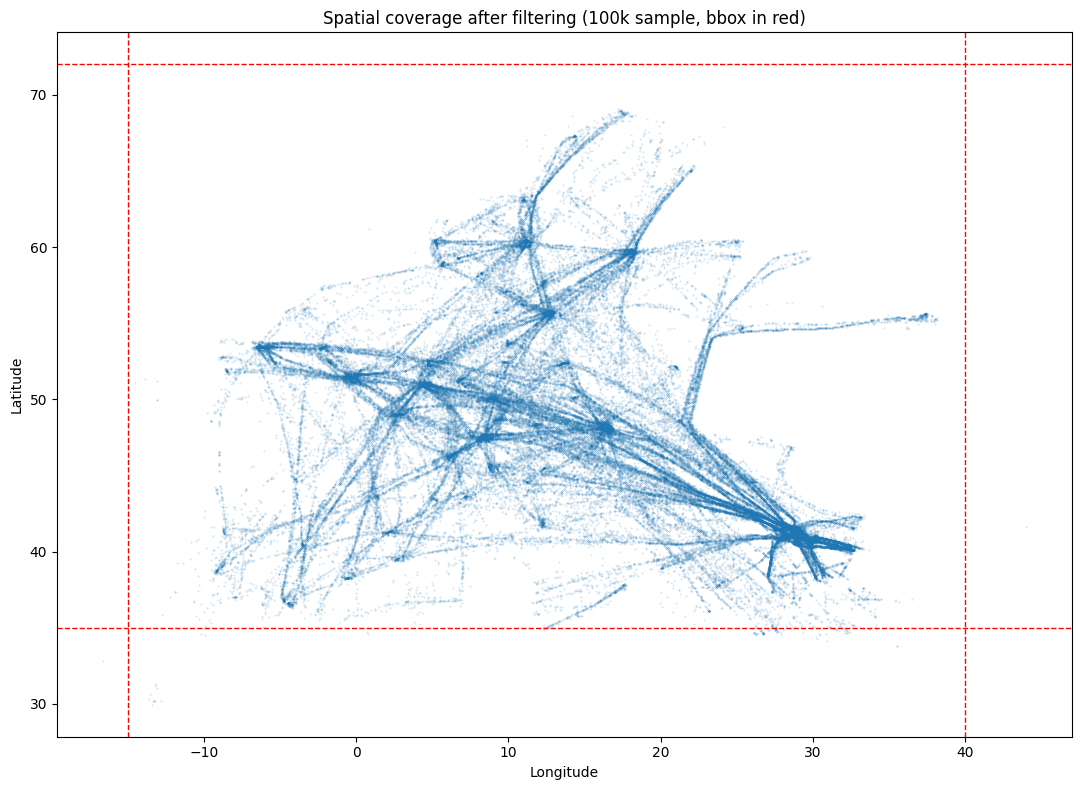

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
sample = df_all[['longitude', 'latitude']].sample(100000, random_state=1321)
ax.scatter(sample['longitude'], sample['latitude'], s=0.1, alpha=0.3)
ax.axhline(LAT_MIN, color='red', ls='--', lw=1)
ax.axhline(LAT_MAX, color='red', ls='--', lw=1)
ax.axvline(LON_MIN, color='red', ls='--', lw=1)
ax.axvline(LON_MAX, color='red', ls='--', lw=1)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial coverage after filtering (100k sample, bbox in red)')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_check.png'), dpi=150, bbox_inches='tight')
plt.show()

### Распределение длительностей рейсов

Ожидаемая медиана ~68 мин, длинный правый хвост до ~300 мин. Без провалов и подозрительных пиков, фильтрация не вносит искажений.

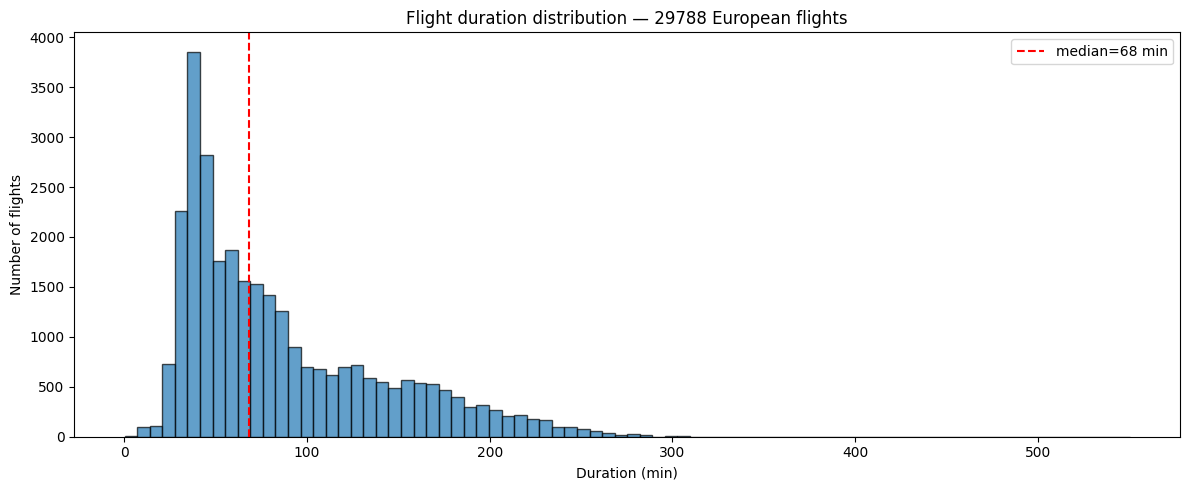

In [ ]:
flight_durations = (
    df_all.groupby('flight_id')['timestamp']
    .agg(['min', 'max'])
)
flight_durations['duration_min'] = (
    (flight_durations['max'] - flight_durations['min']).dt.total_seconds() / 60
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(flight_durations['duration_min'], bins=80, edgecolor='black', alpha=0.7)
ax.set_xlabel('Duration (min)')
ax.set_ylabel('Number of flights')
ax.set_title(f'Flight duration distribution, {len(flight_durations)} European flights')
ax.axvline(flight_durations['duration_min'].median(), color='red', ls='--',
           label=f'median={flight_durations["duration_min"].median():.0f} min')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'flight_durations.png'), dpi=150, bbox_inches='tight')
plt.show()

del flight_durations

## 7. Очистка

In [ ]:
# Удаляем временные чанки
for cf in chunk_files:
    if os.path.exists(cf):
        os.remove(cf)
        print(f'  removed {os.path.basename(cf)}')

print(f'\nFinal output: {output_path}')
print(f'Rows: {len(df_all):,}, Flights: {df_all["flight_id"].nunique()}')
print('Done.')

  removed chunk_00.parquet
  removed chunk_01.parquet
  removed chunk_02.parquet
  removed chunk_03.parquet
  removed chunk_04.parquet
  removed chunk_05.parquet
  removed chunk_06.parquet
  removed chunk_07.parquet
  removed chunk_08.parquet
  removed chunk_09.parquet
  removed chunk_10.parquet
  removed chunk_11.parquet
  removed chunk_12.parquet
  removed chunk_13.parquet

Final output: /content/drive/MyDrive/thesis_processed/european_flights_clean_v3.parquet
Rows: 149,129,454, Flights: 29788
Done.


## Сводка по preprocessing

### Входные данные

234.6 млн ADS-B сообщений, ~37 700 рейсов из 14 parquet-файлов (1-14 ноября 2022). Источник EUROCONTROL PRC 2024 Data Challenge, траектории OpenSky Network с метеоданными ERA5.

### Шаг 1. Пространственная фильтрация

Европейский bbox: lat 35-72°, lon −15-40°. Рейс считается европейским при ≥95% точек в bbox. Фильтрация целыми рейсами (не точками) сохраняет фазы взлёта и посадки приграничных рейсов, критичные для LSTM-autoencoder.

### Шаг 2. Дедупликация (owner-механизм)

Каждому рейсу назначается файл-владелец по первому появлению. Каждый файл обрабатывает только свои рейсы, дубликаты исключены.

### Шаг 3. Threshold filter

Физически невозможные значения заменяются на NaN. Сохраняются `*_threshold_bad` флаги:
- altitude ∉ [−500, 60 000] ft;
- groundspeed > 600 kts;
- |vertical_rate| > 10 000 ft/min.

### Шаг 4. Spike filter

Двухсторонняя проверка через левую и правую медианы (sides_agree). Spike-фильтр сохраняет threshold-NaN, без молчаливой импутации. Сохраняются `*_spike_corrected` флаги.

### Шаг 5. Stale altitude detection (run-level)

altitude константна (в пределах ALT_STALE_TOL = ±25 ft) на длительности ≥ STALE_ALT_MIN_POINTS = 60 последовательных samples (~60 секунд при 1 Гц), при этом доля валидных VR-точек внутри run с |VR| > STALE_VR_THRESHOLD = 500 ft/min составляет ≥ STALE_ACTIVE_SHARE = 0.5.

Sensitivity analysis на random sample 3000 рейсов из всего датасета (вынесен в `02_preprocessing_v3_diagnostics`) показывает: результат устойчив к выбору active_share threshold в широком диапазоне 0.3-0.9 (максимальное отклонение от baseline 2.7%). Выбор 0.5 находится в центре стабильного плато. Физическая причина устойчивости: stale-сегменты бимодальны, большинство имеют либо очень высокую (>0.9), либо очень низкую (<0.3) долю активных VR-точек, промежуточные случаи редки.

На итоговом датасете stale_altitude помечен у 1 785 068 точек (1.197%), сосредоточенных в 6 530 рейсах из 29 788 (21.92%). Median длина stale-сегмента в затронутых рейсах = 292 точки (~5% длины рейса), max = 3 823 точки (54.7% длины рейса 256999095). Распределение указывает на систематический характер явления, а не редкие выбросы.

### Шаг 6. Feature engineering

Wide differencing (N=5, окно 10 секунд):
- acceleration (kts/s), turn_rate (deg/s), vertical_accel (ft/min/s);
- wind_speed (м/с), headwind (м/с), crosswind (м/с), проверены unit-тестом.

### Шаг 7. Quality check

Проверки: shape, dtypes, missing values, DQ flag counts, value ranges, temporal continuity (dt_sec percentiles), spatial coverage, flight duration distribution.

### Итог: финальный датасет

21 колонка = 5 metadata + 9 модельных признаков + 7 DQ-флагов.

| Группа | Колонки |
|---|---|
| Metadata (5) | flight_id, timestamp, latitude, longitude, icao24 |
| Model features (9) | altitude, groundspeed, vertical_rate, acceleration, turn_rate, vertical_accel, wind_speed, headwind, crosswind |
| Threshold flags (3) | altitude_threshold_bad, groundspeed_threshold_bad, vertical_rate_threshold_bad |
| Spike correction flags (3) | altitude_spike_corrected, groundspeed_spike_corrected, vertical_rate_spike_corrected |
| Stale flag (1) | stale_altitude |